# Setup

In [ ]:
!pip install keras-tuner gensim logomaker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 3.0 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
from sklearn.model_selection import train_test_split
from gensim.models import FastText
from collections import Counter

In [ ]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
if tf.config.list_physical_devices('GPU'):
    print("GPU is available and being used.")
else:
    print("No GPU detected. TensorFlow will run on CPU.")

Num GPUs Available:  1
GPU is available and being used.


# Data preperation

In [ ]:
def load_sequences(filepath):
    """Loads sequences from a text file, one sequence per line."""
    with open(filepath, 'r') as f:
        return [line.strip() for line in f]

def load_binding_data(filepath):
    """Loads binding strength data from a space/tab-separated file."""
    return np.loadtxt(filepath)

In [ ]:
full_rbp_sequences = load_sequences('sample_data/training_RBPs2.txt')
# Load DNA sequences (which contain 'U' as per example, implying RNA-like)
full_dna_sequences = load_sequences('sample_data/training_seqs.txt')
# Load the binding strength matrix
full_binding_data = load_binding_data('sample_data/training_data2.txt')

print(f"Loaded {len(full_rbp_sequences)} total RBP sequences.")
print(f"Loaded {len(full_dna_sequences)} total DNA/RNA sequences.")
print(f"Loaded binding data matrix of shape: {full_binding_data.shape}")

Loaded 200 total RBP sequences.
Loaded 120678 total DNA/RNA sequences.
Loaded binding data matrix of shape: (120678, 200)


In [ ]:

# --- Select a smaller subset of data ---
NUM_RBPS_SUBSET = 50
NUM_DNA_SUBSET = 50000

# Ensure we don't try to select more than available
num_rbps_to_use = min(NUM_RBPS_SUBSET, len(full_rbp_sequences))
num_dna_to_use = min(NUM_DNA_SUBSET, len(full_dna_sequences))

# Select the first N RBPs and M DNA sequences for simplicity
rbp_sequences = full_rbp_sequences[:num_rbps_to_use]
dna_sequences = full_dna_sequences[:num_dna_to_use]

# Adjust the binding data matrix to match the selected subsets
binding_data = full_binding_data[:num_dna_to_use, :num_rbps_to_use]

print(f"\nUsing {len(rbp_sequences)} RBP sequences for subset.")
print(f"Using {len(dna_sequences)} DNA/RNA sequences for subset.")
print(f"Subset binding data matrix of shape: {binding_data.shape}")


Using 50 RBP sequences for subset.
Using 50000 DNA/RNA sequences for subset.
Subset binding data matrix of shape: (50000, 50)


In [ ]:
def generate_kmers(sequence, k=3):
    """Generates non-overlapping k-mers from a sequence."""
    if len(sequence) < k:
        return [] # Return empty list if sequence is shorter than k-mer size
    return [sequence[i:i+k] for i in range(0, len(sequence) - k + 1, k)]

In [ ]:
RBP_KMER_SIZE = 3
RBP_EMBEDDING_DIM = 50 # As requested for DNA, applying to RBP as well

# Generate k-mer sequences for RBP
rbp_kmer_sequences = [generate_kmers(seq, k=RBP_KMER_SIZE) for seq in rbp_sequences]
print(len(rbp_kmer_sequences))

50


In [ ]:
DNA_KMER_SIZE = 3
DNA_EMBEDDING_DIM = 50 # As requested

# Generate k-mer sequences for DNA
dna_kmer_sequences = [generate_kmers(seq, k=DNA_KMER_SIZE) for seq in dna_sequences]
print(len(dna_kmer_sequences))

50000


In [ ]:
all_dna_kmers = [kmer for seq_kmers in dna_kmer_sequences for kmer in seq_kmers]
dna_kmer_vocab = sorted(list(set(all_dna_kmers)))
# Map k-mers to integers starting from 1, reserving 0 for padding.
dna_kmer_to_int = {kmer: i + 1 for i, kmer in enumerate(dna_kmer_vocab)}

# Encode k-mer sequences into integer sequences
encoded_dna_kmer_sequences = [
    [dna_kmer_to_int.get(kmer, 0) for kmer in seq_kmers] # Use .get(kmer, 0) for safety
    for seq_kmers in dna_kmer_sequences
]

all_rbp_kmers = [kmer for seq_kmers in rbp_kmer_sequences for kmer in seq_kmers]
rbp_kmer_vocab = sorted(list(set(all_rbp_kmers)))
# Map RBP k-mers to integers starting from 1, reserving 0 for padding.
rbp_kmer_to_int = {kmer: i + 1 for i, kmer in enumerate(rbp_kmer_vocab)}

# Encode RBP k-mer sequences into integer sequences
encoded_rbp_kmer_sequences = [
    [rbp_kmer_to_int.get(kmer, 0) for kmer in seq_kmers] # Use .get(kmer, 0) for safety
    for seq_kmers in rbp_kmer_sequences
]

In [ ]:
# Determine max length for padded RBP k-mer sequences
max_rbp_kmer_len = max(len(seq) for seq in encoded_rbp_kmer_sequences) if encoded_rbp_kmer_sequences else 0
# Pad RBP k-mer sequences
padded_rbp_kmer_sequences = keras.preprocessing.sequence.pad_sequences(
    encoded_rbp_kmer_sequences, maxlen=max_rbp_kmer_len, padding='post'
)

# Determine max length for padded k-mer sequences
max_dna_kmer_len = max(len(seq) for seq in encoded_dna_kmer_sequences) if encoded_dna_kmer_sequences else 0
# Pad k-mer sequences
padded_dna_kmer_sequences = keras.preprocessing.sequence.pad_sequences(
    encoded_dna_kmer_sequences, maxlen=max_dna_kmer_len, padding='post'
)

print(f"\nMax RBP k-mer sequence length: {max_rbp_kmer_len}")
print(f"Shape of padded RBP k-mer sequences: {padded_rbp_kmer_sequences.shape}")
print(f"Number of unique RBP k-mers (vocabulary size): {len(rbp_kmer_vocab)}")

print(f"\nMax DNA k-mer sequence length: {max_dna_kmer_len}")
print(f"Shape of padded DNA k-mer sequences: {padded_dna_kmer_sequences.shape}")
print(f"Number of unique DNA k-mers (vocabulary size): {len(dna_kmer_vocab)}")


Max RBP k-mer sequence length: 185
Shape of padded RBP k-mer sequences: (50, 185)
Number of unique RBP k-mers (vocabulary size): 2455

Max DNA k-mer sequence length: 13
Shape of padded DNA k-mer sequences: (50000, 13)
Number of unique DNA k-mers (vocabulary size): 64


In [ ]:
padded_rbp_kmer_sequences[3,:]  #Here's what an example sequence looks like

array([   8, 1604,  411, 1173,  185,  772,  205, 1098, 1145,  801, 1972,
       1315,  387, 1383, 1837,  190,  671,  925,  222,  546, 1382, 1427,
        190, 1836, 1550,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,   

In [ ]:
padded_dna_kmer_sequences[3,:]  #Here's what an example sequence looks like

array([ 9,  1,  1, 17, 33, 64, 54, 59, 58, 16, 44,  0,  0], dtype=int32)

In [ ]:
print("\nTraining FastText model for RBP k-mers...")
fasttext_model_rbp = FastText(
    sentences=rbp_kmer_sequences,
    vector_size=RBP_EMBEDDING_DIM,
    window=25,
    min_count=1, # Ensures all k-mers are considered
    sg=0, # CBOW
    min_n=2,
    max_n=3
)
print("FastText model training complete for RBP.")

# Create embedding matrix for Keras RBP Embedding layer
embedding_matrix_rbp = np.zeros((len(rbp_kmer_vocab) + 1, RBP_EMBEDDING_DIM))
for kmer, i in rbp_kmer_to_int.items():
    if kmer in fasttext_model_rbp.wv:
        embedding_matrix_rbp[i] = fasttext_model_rbp.wv[kmer]
print(f"Shape of RBP embedding matrix: {embedding_matrix_rbp.shape}")

print("\nTraining FastText model for DNA k-mers...")
fasttext_model_dna = FastText(
    sentences=dna_kmer_sequences,
    vector_size=DNA_EMBEDDING_DIM,
    window=25,
    min_count=1,
    sg=0,
    min_n=2,
    max_n=3
)
print("FastText model training complete for DNA.")

# Create embedding matrix for Keras DNA Embedding layer
embedding_matrix_dna = np.zeros((len(dna_kmer_vocab) + 1, DNA_EMBEDDING_DIM))
for kmer, i in dna_kmer_to_int.items():
    if kmer in fasttext_model_dna.wv:
        embedding_matrix_dna[i] = fasttext_model_dna.wv[kmer]
print(f"Shape of DNA embedding matrix: {embedding_matrix_dna.shape}")


Training FastText model for RBP k-mers...
FastText model training complete for RBP.
Shape of RBP embedding matrix: (2456, 50)

Training FastText model for DNA k-mers...
FastText model training complete for DNA.
Shape of DNA embedding matrix: (65, 50)


In [ ]:
num_dna_seqs = padded_dna_kmer_sequences.shape[0]
num_rbp_seqs = padded_rbp_kmer_sequences.shape[0]

# Generate all possible (dna_idx, rbp_idx) combinations
all_combination_indices = []
for i in range(num_dna_seqs):
    for j in range(num_rbp_seqs):
        all_combination_indices.append((i, j))

print(f"\nTotal samples (combinations) generated: {len(all_combination_indices)}")


Total samples (combinations) generated: 2500000


In [ ]:
train_indices, test_indices = train_test_split(
    all_combination_indices,
    test_size=0.2, # 20% of data for testing
    random_state=42 # For reproducibility
)

print(f"\nTraining samples: {len(train_indices)}")
print(f"Testing samples: {len(test_indices)}")


Training samples: 2000000
Testing samples: 500000


In [ ]:
class DataGenerator(keras.utils.Sequence):
    'Generates data for Keras'
    def __init__(self, list_indices, padded_dna_seqs, padded_rbp_seqs, binding_data, batch_size=32, shuffle=True):
        self.list_indices = list_indices # List of (dna_idx, rbp_idx) tuples
        self.padded_dna_seqs = padded_dna_seqs
        self.padded_rbp_seqs = padded_rbp_seqs
        self.binding_data = binding_data
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        'Denotes the number of batches per epoch'
        return int(np.floor(len(self.list_indices) / self.batch_size))

    def __getitem__(self, index):
        'Generate one batch of data'
        # Generate indices of the batch within self.list_indices
        indices_in_batch = self.indices[index*self.batch_size:(index+1)*self.batch_size]

        # Get the actual (dna_idx, rbp_idx) tuples for the current batch
        batch_combination_indices = [self.list_indices[k] for k in indices_in_batch]

        # Generate data for this batch
        X_dna, X_rbp, y = self.__data_generation(batch_combination_indices)
        return {'dna_input': X_dna, 'rbp_input': X_rbp}, y

    def on_epoch_end(self):
        'Updates indices after each epoch'
        self.indices = np.arange(len(self.list_indices))
        if self.shuffle == True:
            np.random.shuffle(self.indices)

    def __data_generation(self, batch_combination_indices):
        'Generates data containing batch_size samples'
        # Pre-allocate arrays for efficiency
        X_dna_batch = np.empty((len(batch_combination_indices), self.padded_dna_seqs.shape[1]), dtype=self.padded_dna_seqs.dtype)
        X_rbp_batch = np.empty((len(batch_combination_indices), self.padded_rbp_seqs.shape[1]), dtype=self.padded_rbp_seqs.dtype)
        y_batch = np.empty((len(batch_combination_indices),), dtype=self.binding_data.dtype)

        for i, (dna_idx, rbp_idx) in enumerate(batch_combination_indices):
            X_dna_batch[i] = self.padded_dna_seqs[dna_idx]
            X_rbp_batch[i] = self.padded_rbp_seqs[rbp_idx]
            y_batch[i] = self.binding_data[dna_idx, rbp_idx]

        return X_dna_batch, X_rbp_batch, y_batch

In [ ]:
train_generator = DataGenerator(
    train_indices,
    padded_dna_kmer_sequences,
    padded_rbp_kmer_sequences,
    binding_data,
    batch_size=256,
    shuffle=True
)

test_generator = DataGenerator(
    test_indices,
    padded_dna_kmer_sequences,
    padded_rbp_kmer_sequences,
    binding_data,
    batch_size=256,
    shuffle=False # No need to shuffle test data
)

# LSTM Model

In [ ]:
class Attention(layers.Layer):
    """
    A custom Keras Attention layer that computes a context vector from a sequence.
    It implements a form of additive attention (Bahdanau-style).
    """
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)
        # Indicate that this layer supports masking, which is important for padded sequences.
        self.supports_masking = True

    def build(self, input_shape):
        # input_shape: (batch_size, sequence_length, hidden_size)
        hidden_size = input_shape[-1]

        # Weight matrix for the input sequence (H)
        self.W = self.add_weight(name='att_weight_W', shape=(hidden_size, hidden_size),
                               initializer='glorot_uniform', trainable=True)
        # Bias vector
        self.b = self.add_weight(name='att_bias_b', shape=(hidden_size,),
                               initializer='zeros', trainable=True)
        # Context vector (u) that learns what to attend to
        self.u = self.add_weight(name='att_context_u', shape=(hidden_size, 1),
                               initializer='glorot_uniform', trainable=True)
        super(Attention, self).build(input_shape)

    def call(self, inputs, mask=None):
        # inputs shape: (batch_size, sequence_length, hidden_size)

        # Step 1: Compute alignment scores
        # uit = tanh(H * W + b)
        uit = keras.backend.tanh(keras.backend.dot(inputs, self.W) + self.b)

        # ait = u^T * uit (score before softmax)
        ait = keras.backend.dot(uit, self.u)
        # Remove the last dimension (which is 1 after dot product with self.u)
        ait = keras.backend.squeeze(ait, -1) # Result shape: (batch_size, sequence_length)

        # Step 2: Apply mask to attention scores if available
        if mask is not None:
            # Keras mask is typically 1 for valid steps and 0 for padded steps.
            # We want to set scores for padded steps to a very small number
            # so that their softmax probability becomes close to zero.
            mask = keras.backend.cast(mask, keras.backend.floatx())
            # Add a large negative number to masked positions (where mask is 0)
            ait += (mask - 1) * 1e9 # (0-1)*1e9 = -1e9, (1-1)*1e9 = 0

        # Step 3: Compute attention weights (alphas) using softmax
        alphas = keras.backend.softmax(ait) # Result shape: (batch_size, sequence_length)

        # Step 4: Compute the context vector
        # Apply attention weights to the original inputs and sum them up
        # Expand alphas dimension to match inputs for element-wise multiplication
        output = inputs * keras.backend.expand_dims(alphas, -1)
        # Sum over the sequence length dimension to get the context vector
        output = keras.backend.sum(output, axis=1) # Result shape: (batch_size, hidden_size)

        # Return both the context vector and the attention weights (alphas)
        return output, alphas # Return alphas for interpretability

    def compute_output_shape(self, input_shape):
        # The output shape is now a list of two shapes: (context_vector_shape, alphas_shape)
        hidden_size = input_shape[-1]
        sequence_length = input_shape[1]
        return [(input_shape[0], hidden_size), (input_shape[0], sequence_length)]

    def get_config(self):
        # Required for saving and loading models with custom layers
        config = super(Attention, self).get_config()
        return config

In [ ]:
from pathlib import Path

MODEL_EXPORT_PATH =
saved_model_path = Path("lstm_model.keras")

In [ ]:
lstm_units = 64     # Number of units in each LSTM layer (Bidirectional will double this effectively)

if saved_model_path.exists():
    print("\n--- Loading a saved Model ---")
    model = keras.models.load_model(str(saved_model_path))
else:
    print("\n--- Creating Model ---")
    # --- DNA Branch (using FastText embeddings) ---
    dna_input = keras.Input(shape=(max_dna_kmer_len,), name='dna_input')
    # Embedding layer for DNA k-mer sequences, initialized with FastText weights.
    # trainable=False means these embeddings are not updated during training.
    dna_embedding = layers.Embedding(
        input_dim=len(dna_kmer_vocab) + 1, # Vocabulary size (+1 for padding)
        output_dim=DNA_EMBEDDING_DIM, # FastText embedding dimension
        weights=[embedding_matrix_dna], # Pre-trained FastText embeddings
        trainable=False, # Do not fine-tune FastText embeddings
        mask_zero=True # Ensures padded zeros are ignored
    )(dna_input)
    # First Bidirectional LSTM layer. return_sequences=True to pass sequence to next layer.
    dna_bilstm_1 = layers.Bidirectional(layers.LSTM(lstm_units, return_sequences=True))(dna_embedding)
    # Second Bidirectional LSTM layer. return_sequences=True as attention needs a sequence.
    dna_bilstm_2 = layers.Bidirectional(layers.LSTM(lstm_units, return_sequences=True))(dna_bilstm_1)
    # Attention layer to get a single context vector for DNA
    dna_attention_vector, dna_attention_alphas = Attention(name='dna_attention')(dna_bilstm_2)

    # --- RBP Branch (using FastText embeddings) ---
    rbp_input = keras.Input(shape=(max_rbp_kmer_len,), name='rbp_input')
    # Embedding layer for RBP k-mer sequences, initialized with FastText weights.
    rbp_embedding = layers.Embedding(
        input_dim=len(rbp_kmer_vocab) + 1, # Vocabulary size (+1 for padding)
        output_dim=RBP_EMBEDDING_DIM, # FastText embedding dimension
        weights=[embedding_matrix_rbp], # Pre-trained FastText embeddings
        trainable=False, # Do not fine-tune FastText embeddings
        mask_zero=True # Ensures padded zeros are ignored
    )(rbp_input)
    # First Bidirectional LSTM layer
    rbp_bilstm_1 = layers.Bidirectional(layers.LSTM(lstm_units, return_sequences=True))(rbp_embedding)
    # Second Bidirectional LSTM layer
    rbp_bilstm_2 = layers.Bidirectional(layers.LSTM(lstm_units, return_sequences=True))(rbp_bilstm_1)
    # Attention layer to get a single context vector for RBP
    rbp_attention_vector, rbp_attention_alphas = Attention(name='rbp_attention')(rbp_bilstm_2)

    # --- Concatenate and MLP for prediction ---
    # Concatenate the attention vectors from both branches
    concatenated = layers.concatenate([dna_attention_vector, rbp_attention_vector], name='concatenated_vectors')

    # Multi-Layer Perceptron (MLP)
    mlp_output = layers.Dense(128, activation='relu', name='mlp_dense_1')(concatenated)
    mlp_output = layers.Dropout(0.3)(mlp_output) # Dropout for regularization
    mlp_output = layers.Dense(64, activation='relu', name='mlp_dense_2')(mlp_output)
    mlp_output = layers.Dropout(0.3)(mlp_output) # Dropout for regularization

    # Output layer for regression (binding strength). Linear activation for continuous output.
    output_strength = layers.Dense(1, activation='linear', name='binding_strength_output')(mlp_output)

    # Create the Keras Model
    model = keras.Model(inputs=[dna_input, rbp_input], outputs=output_strength, name='RBP_DNA_Binding_Predictor')
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [ ]:
## Note that most of the parameters come from the embedding layer
model.summary()

Model: "RBP_DNA_Binding_Predictor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ dna_input           │ (None, 13)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rbp_input           │ (None, 185)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_10        │ (None, 13, 50)    │      3,250 │ dna_input[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_10        │ (None, 13)        │          0 │ dna_input[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_11        │ (None, 185, 50)   │    122,800 │ rbp_input[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_11        │ (None, 185)       │          0 │ rbp_input[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_20    │ (None, 13, 128)   │     58,880 │ embedding_10[0][… │
│ (Bidirectional)     │                   │            │ not_equal_10[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_22    │ (None, 185, 128)  │     58,880 │ embedding_11[0][… │
│ (Bidirectional)     │                   │            │ not_equal_11[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_21    │ (None, 13, 128)   │     98,816 │ bidirectional_20… │
│ (Bidirectional)     │                   │            │ not_equal_10[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_23    │ (None, 185, 128)  │     98,816 │ bidirectional_22… │
│ (Bidirectional)     │                   │            │ not_equal_11[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dna_attention       │ [(None, 128),     │     16,640 │ bidirectional_21… │
│ (Attention)         │ (None, 13)]       │            │ not_equal_10[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rbp_attention       │ [(None, 128),     │     16,640 │ bidirectional_23… │
│ (Attention)         │ (None, 185)]      │            │ not_equal_11[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenated_vecto… │ (None, 256)       │          0 │ dna_attention[0]… │
│ (Concatenate)       │                   │            │ rbp_attention[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_dense_1 (Dense) │ (None, 128)       │     32,896 │ concatenated_vec… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 128)       │          0 │ mlp_dense_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_dense_2 (Dense) │ (None, 64)        │      8,256 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 64)        │          0 │ mlp_dense_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ binding_strength_o… │ (None, 1)         │         65 │ dropout_9[0][0]   │
│ (Dense)             │                   │            │                 

 Total params: 515,939 (1.97 MB)

 Trainable params: 389,889 (1.49 MB)

 Non-trainable params: 126,050 (492.38 KB)

# Training

In [ ]:
if saved_model_path.exists():
    print("\n--- Skipping saved model training ---")
else:
    print("\n--- Training Model ---")
    history = model.fit(
        train_generator, # Use the training data generator
        epochs=10, # Number of training epochs. Adjust as needed.
        validation_data=test_generator, # Use the test generator for validation
        verbose=1 # Show progress bar during training
    )


--- Training Model ---
Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


7812/7812 ━━━━━━━━━━━━━━━━━━━━ 791s 100ms/step - loss: 0.1389 - mae: 0.2660 - val_loss: 0.0676 - val_mae: 0.1749
Epoch 2/10
7812/7812 ━━━━━━━━━━━━━━━━━━━━ 731s 94ms/step - loss: 0.0702 - mae: 0.1811 - val_loss: 0.0641 - val_mae: 0.1712
Epoch 3/10
7812/7812 ━━━━━━━━━━━━━━━━━━━━ 729s 93ms/step - loss: 0.0656 - mae: 0.1755 - val_loss: 0.0605 - val_mae: 0.1650
Epoch 4/10
7812/7812 ━━━━━━━━━━━━━━━━━━━━ 728s 93ms/step - loss: 0.0630 - mae: 0.1728 - val_loss: 0.0606 - val_mae: 0.1700
Epoch 5/10
7812/7812 ━━━━━━━━━━━━━━━━━━━━ 758s 97ms/step - loss: 0.0608 - mae: 0.1705 - val_loss: 0.0572 - val_mae: 0.1632
Epoch 6/10
7812/7812 ━━━━━━━━━━━━━━━━━━━━ 803s 103ms/step - loss: 0.0580 - mae: 0.1684 - val_loss: 0.0555 - val_mae: 0.1618
Epoch 7/10
7812/7812 ━━━━━━━━━━━━━━━━━━━━ 795s 102ms/step - loss: 0.0564 - mae: 0.1668 - val_loss: 0.0536 - val_mae: 0.1589
Epoch 8/10
7812/7812 ━━━━━━━━━━━━━━━━━━━━ 824s 106ms/step - loss: 0.0546 - mae: 0.1651 - val_loss: 0.0528 - val_mae: 0.1576
Epoch 9/10
7812/7812 ━━

In [ ]:
print("\n--- Evaluating Model on Test Set ---")
loss, mae = model.evaluate(
    test_generator, # Use the test data generator for evaluation
    verbose=0 # Do not show progress bar during evaluation
)

print(f"\nTest Loss (Mean Squared Error - MSE): {loss:.4f}")
print(f"Test Mean Absolute Error (MAE): {mae:.4f}")


--- Evaluating Model on Test Set ---

Test Loss (Mean Squared Error - MSE): 0.0532
Test Mean Absolute Error (MAE): 0.1590


# Diagnosis

In [ ]:
from scipy.stats import pearsonr, spearmanr # For calculating Spearman/Pearson correlation

In [ ]:
print("\n--- Diagnosing Prediction Bias ---")

# First, get all actual and predicted values for the test set
all_test_predictions = []
all_test_actuals = []

# Iterate through the test_generator to get all predictions and actuals
for i in range(len(test_generator)):
    inputs, actuals = test_generator.__getitem__(i)[:2] # Get inputs and actuals (ignore sample_weights)
    predictions_batch = model.predict(inputs, verbose=0).flatten()
    all_test_predictions.extend(predictions_batch)
    all_test_actuals.extend(actuals)

all_test_predictions = np.array(all_test_predictions)
all_test_actuals = np.array(all_test_actuals)


--- Diagnosing Prediction Bias ---


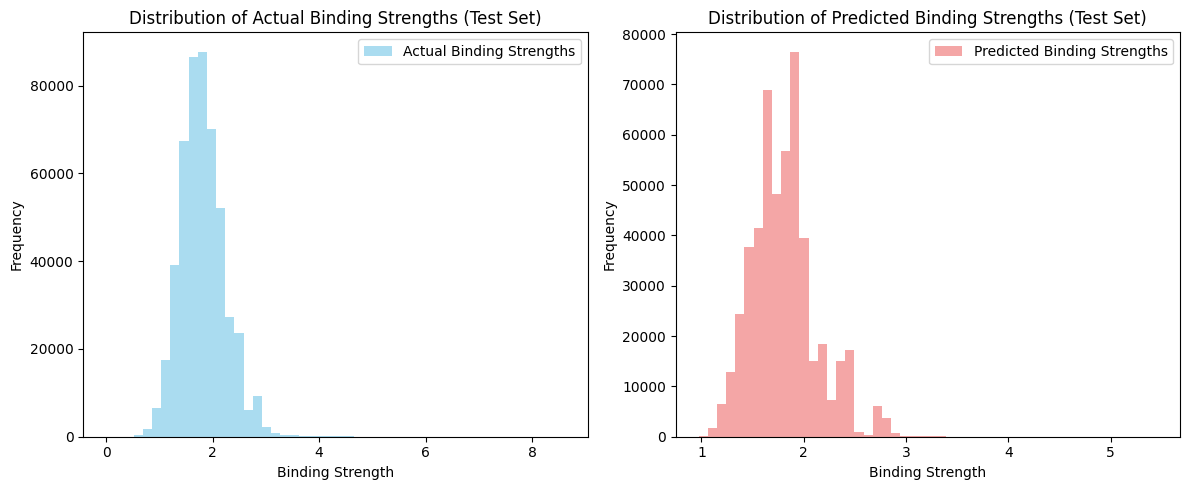

Standard Deviation of Actual Binding Strengths: 0.4193
Standard Deviation of Predicted Binding Strengths: 0.3201


In [ ]:
# Plot histograms
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(all_test_actuals, bins=50, alpha=0.7, label='Actual Binding Strengths', color='skyblue')
plt.title('Distribution of Actual Binding Strengths (Test Set)')
plt.xlabel('Binding Strength')
plt.ylabel('Frequency')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(all_test_predictions, bins=50, alpha=0.7, label='Predicted Binding Strengths', color='lightcoral')
plt.title('Distribution of Predicted Binding Strengths (Test Set)')
plt.xlabel('Binding Strength')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()

# Calculate and print standard deviation for the entire test set
std_actual_test_set = np.std(all_test_actuals)
std_prediction_test_set = np.std(all_test_predictions)
print(f"Standard Deviation of Actual Binding Strengths: {std_actual_test_set:.4f}")
print(f"Standard Deviation of Predicted Binding Strengths: {std_prediction_test_set:.4f}")

In [ ]:
# Calculate Pearson Correlation Coefficient
correlation, _ = pearsonr(all_test_actuals, all_test_predictions)
print(f"Pearson Correlation Coefficient (Actual vs. Predicted): {correlation:.4f}")
# Calculate Spearman Correlation Coefficient
correlation, _ = spearmanr(all_test_actuals, all_test_predictions)
print(f"Spearman Correlation Coefficient (Actual vs. Predicted): {correlation:.4f}")

Pearson Correlation Coefficient (Actual vs. Predicted): 0.8387
Spearman Correlation Coefficient (Actual vs. Predicted): 0.8245


In [ ]:
# Check performance on high binding strength samples
# Define a threshold for "high" binding strength (e.g., top 1% or 5% of the range)
high_binding_threshold = np.percentile(all_test_actuals, 97)
high_binding_indices = np.where(all_test_actuals >= high_binding_threshold)[0]

if len(high_binding_indices) > 0:
    high_binding_actuals = all_test_actuals[high_binding_indices]
    high_binding_predictions = all_test_predictions[high_binding_indices]
    mae_high_binding = np.mean(np.abs(high_binding_actuals - high_binding_predictions))
    std_actual_high_binding = np.std(high_binding_actuals) # Calculate standard deviation for actual high binding
    std_predicted_high_binding = np.std(high_binding_predictions) # Calculate standard deviation for predicted high binding

    print(f"Threshold for 'high' binding strength (95th percentile): {high_binding_threshold:.4f}")
    print(f"MAE on 'high' binding strength samples ({len(high_binding_indices)} samples): {mae_high_binding:.4f}")
    print(f"Std Dev of Actual 'high' binding strengths: {std_actual_high_binding:.4f}")
    print(f"Std Dev of Predicted 'high' binding strengths: {std_predicted_high_binding:.4f}")
else:
    print("Not enough 'high' binding strength samples in the test set to evaluate separately.")

Threshold for 'high' binding strength (95th percentile): 2.7170
MAE on 'high' binding strength samples (15001 samples): 0.3843
Std Dev of Actual 'high' binding strengths: 0.3438
Std Dev of Predicted 'high' binding strengths: 0.3657


# Interpretability

In [ ]:
import matplotlib.pyplot as plt
import logomaker
import pandas as pd

In [ ]:
def kmer_attention_to_nucleotide_importance(original_sequence, kmer_attention_weights, k_size, chars_list):
    """
    Converts k-mer level attention weights to nucleotide-level importance scores.
    Assumes non-overlapping k-mers.
    Assigns the k-mer's attention score to each nucleotide within it.
    Creates a (sequence_length, num_chars) matrix where each row is a position
    and columns correspond to characters in chars_list.
    """
    seq_len = len(original_sequence)
    num_chars = len(chars_list)
    nucleotide_importance_matrix = np.zeros((seq_len, num_chars))

    # Trim kmer_attention_weights to the actual number of k-mers in the original sequence
    actual_num_kmers = len(generate_kmers(original_sequence, k=k_size))
    kmer_attention_weights_trimmed = kmer_attention_weights[:actual_num_kmers]

    for i, kmer_weight in enumerate(kmer_attention_weights_trimmed):
        start_idx = i * k_size
        end_idx = start_idx + k_size
        for j in range(start_idx, min(end_idx, seq_len)):
            char = original_sequence[j]
            if char in chars_list:
                char_idx = chars_list.index(char)
                nucleotide_importance_matrix[j, char_idx] = kmer_weight
    return nucleotide_importance_matrix

def plot_sequence_logo(nucleotide_importance_matrix, title, chars_list):
    """
    Plots a sequence logo from a nucleotide importance matrix.
    nucleotide_importance_matrix: A 2D numpy array (sequence_length, num_chars)
                                  where values represent importance scores.
    title: Title for the plot.
    chars_list: List of characters corresponding to columns in the matrix (e.g., ['A', 'C', 'G', 'U']).
    """
    if nucleotide_importance_matrix.shape[0] == 0:
        print(f"Cannot plot logo for '{title}': Empty importance matrix.")
        return

    # Create a DataFrame for logomaker
    logo_df = pd.DataFrame(nucleotide_importance_matrix, columns=chars_list)

    plt.figure(figsize=(max(8, logo_df.shape[0] * 0.5), 4)) # Adjust figure size dynamically
    logo = logomaker.Logo(logo_df)

    logo.style_spines(visible=False)
    logo.style_xticks(visible=False) # Hide x-ticks as positions are implicit
    logo.ax.set_ylabel('Attention Weight', labelpad=-1)
    logo.ax.set_title(title)
    plt.tight_layout()
    plt.show()

In [ ]:
# Create a generator for predictions for this RBP across all DNA sequences
# This avoids loading all DNA sequences into memory at once for prediction
class SingleRBP_DNA_PredictGenerator(keras.utils.Sequence):
    def __init__(self, rbp_padded_kmer, all_dna_padded_kmer_seqs, batch_size=32):
        self.rbp_padded_kmer = rbp_padded_kmer
        self.all_dna_padded_kmer_seqs = all_dna_padded_kmer_seqs
        self.batch_size = batch_size

    def __len__(self):
        return int(np.ceil(len(self.all_dna_padded_kmer_seqs) / self.batch_size))

    def __getitem__(self, idx):
        batch_dna_kmer = self.all_dna_padded_kmer_seqs[idx * self.batch_size:(idx + 1) * self.batch_size]
        # Repeat the RBP input for the entire batch
        batch_rbp_kmer = np.repeat(self.rbp_padded_kmer, len(batch_dna_kmer), axis=0)
        return {'dna_input': batch_dna_kmer, 'rbp_input': batch_rbp_kmer}


--- Starting Interpretability Analysis (Sequence Logos) ---

Analyzing DNA sequences for RBP: AAAAGKQIEGPEGCNLFIYHLPQEFTDTDLASTFLPFGNVISAKVFIDKQ...


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


<Figure size 1900x400 with 0 Axes>

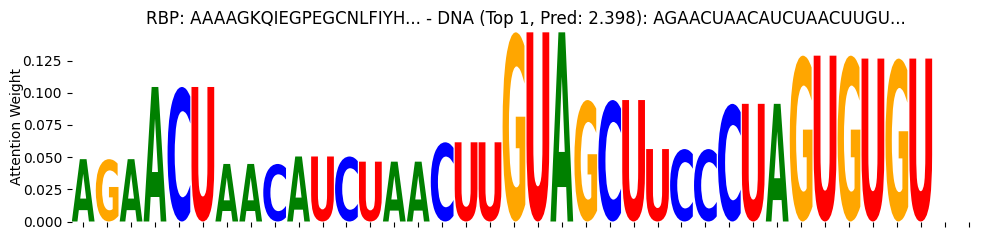

<Figure size 1900x400 with 0 Axes>

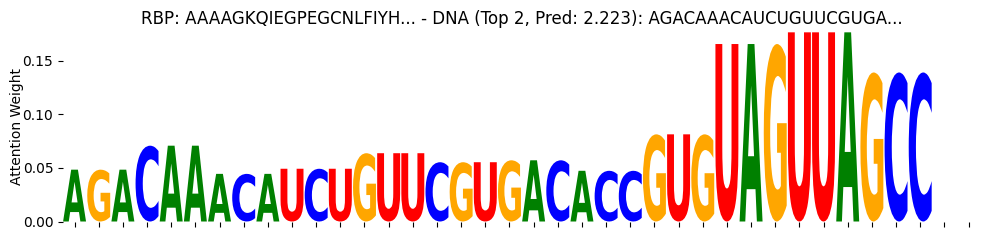

<Figure size 1950x400 with 0 Axes>

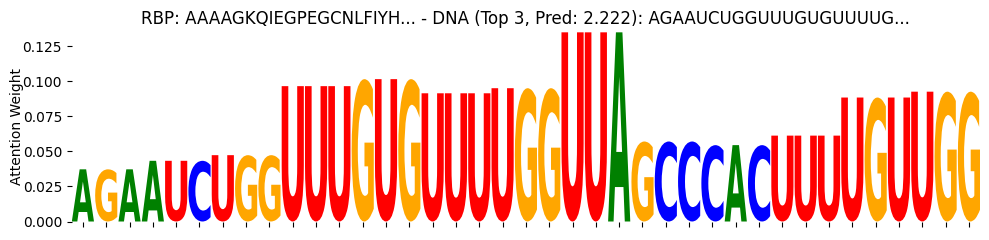


Analyzing DNA sequences for RBP: AAFPNVFTHVERLLDEEIARVRASLFQINGVKKEPLTLPEPEGSVVTMNE...


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


<Figure size 1900x400 with 0 Axes>

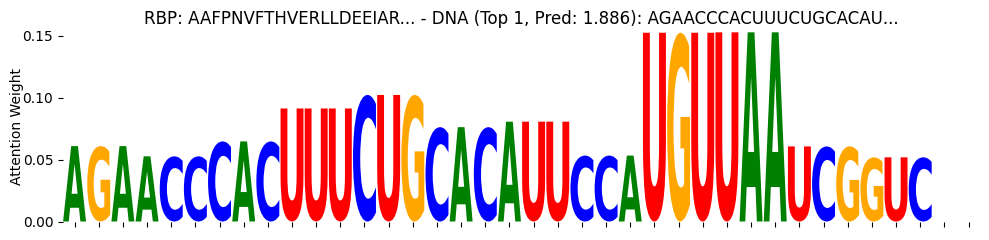

<Figure size 1900x400 with 0 Axes>

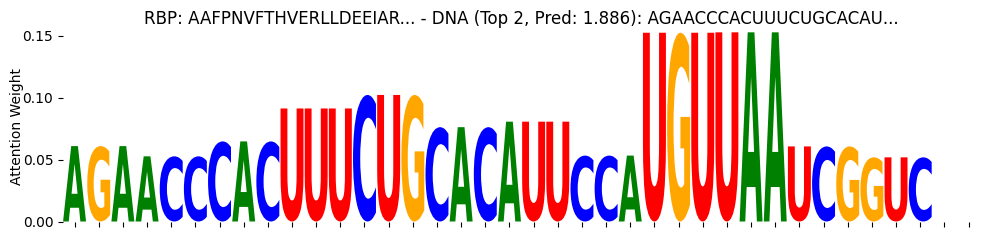

<Figure size 1900x400 with 0 Axes>

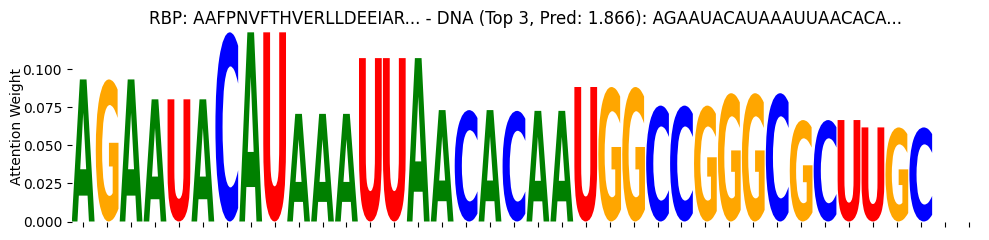


Analyzing DNA sequences for RBP: AANSRQVAATAAAAAAVAAAAGGVGGAPQPGRSRLLEDFRNQRYPNLQLR...


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


<Figure size 1900x400 with 0 Axes>

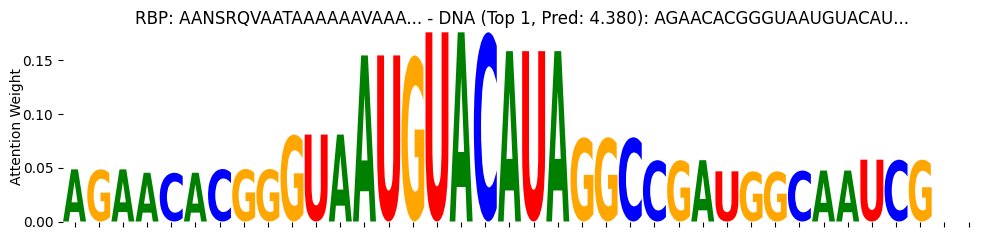

<Figure size 1900x400 with 0 Axes>

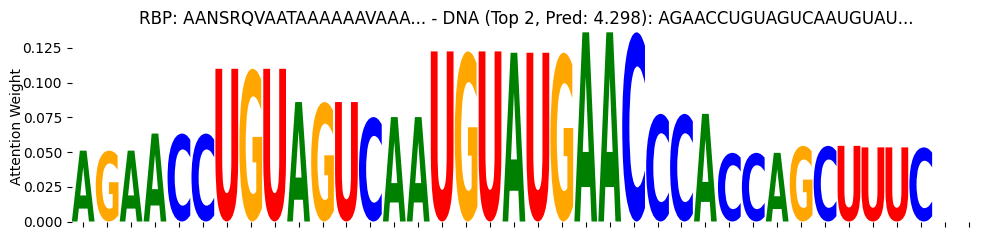

<Figure size 1900x400 with 0 Axes>

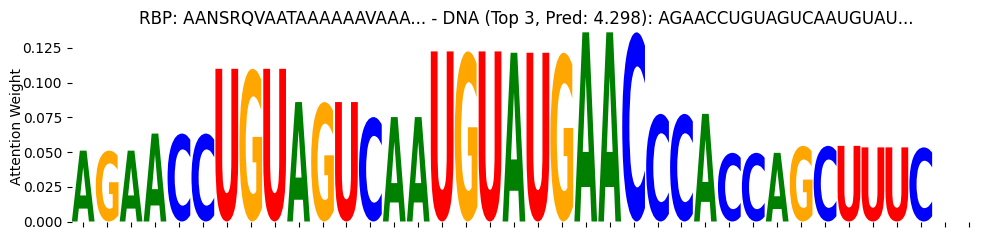


--- Interpretability Analysis Complete ---


In [ ]:
DNA_CHARS = ['A', 'C', 'G', 'U'] # Define DNA characters for sequence logo

print("\n--- Starting Interpretability Analysis (Sequence Logos) ---")

# Create a model that outputs the DNA attention alphas
interpretability_model = keras.Model(inputs=[model.input[0], model.input[1]],
                                     outputs=model.get_layer('dna_attention').output[1]) # Output the alphas
# Choose a few RBPs to analyze (e.g., the first 3 RBPs from the subset)
rbps_to_analyze_indices = range(min(3, num_rbps_to_use)) # Analyze first 3 or fewer if not enough

# For interpretability, we ideally want DNA sequences that bind strongly to a specific RBP.
# For this example, we will randomly select a few DNA sequences from the test set.
# In a real application, you would predict binding strengths for all DNA sequences
# with a given RBP and select the top N binders.
# Number of top DNA sequences to analyze for each RBP
NUM_TOP_DNA_SEQUENCES_FOR_LOGO = 3

for rbp_idx in rbps_to_analyze_indices:
    current_rbp_sequence = rbp_sequences[rbp_idx]
    current_padded_rbp_kmer = padded_rbp_kmer_sequences[rbp_idx:rbp_idx+1] # Keep batch dimension

    print(f"\nAnalyzing DNA sequences for RBP: {current_rbp_sequence[:50]}...") # Print first 50 chars of RBP

    # --- Step 1: Predict binding strengths for all DNA sequences with the current RBP ---
    predicted_strengths_for_rbp = []
    predict_generator = SingleRBP_DNA_PredictGenerator(current_padded_rbp_kmer, padded_dna_kmer_sequences)
    predictions = model.predict(predict_generator, verbose=0).flatten()

    # Store (predicted_strength, dna_idx) for sorting
    dna_predictions_with_indices = []
    for i, pred_strength in enumerate(predictions):
        dna_predictions_with_indices.append((pred_strength, i))

    # Sort by predicted strength in descending order
    dna_predictions_with_indices.sort(key=lambda x: x[0], reverse=True)

    # Select the top N DNA sequences
    top_dna_binders = dna_predictions_with_indices[:NUM_TOP_DNA_SEQUENCES_FOR_LOGO]

    # --- Step 2: Plot Sequence Logos for each selected DNA sequence ---
    if top_dna_binders:
        for i, (predicted_strength, dna_sample_idx) in enumerate(top_dna_binders):
            original_dna_seq = dna_sequences[dna_sample_idx]
            padded_dna_kmer = padded_dna_kmer_sequences[dna_sample_idx:dna_sample_idx+1] # Keep batch dimension

            # Get k-mer attention weights for this specific DNA-RBP pair
            kmer_attention_weights = interpretability_model.predict(
                {'dna_input': padded_dna_kmer, 'rbp_input': current_padded_rbp_kmer},
                verbose=0
            )[0] # Get the first (and only) sample's attention weights

            # Convert k-mer attention to nucleotide importance
            nucleotide_importance_matrix = kmer_attention_to_nucleotide_importance(
                original_dna_seq, kmer_attention_weights, k_size=DNA_KMER_SIZE, chars_list=DNA_CHARS
            )

            # Plot individual sequence logo
            plot_sequence_logo(nucleotide_importance_matrix,
                               f"RBP: {current_rbp_sequence[:20]}... - DNA (Top {i+1}, Pred: {predicted_strength:.3f}): {original_dna_seq[:20]}...",
                               DNA_CHARS)
    else:
        print(f"No top DNA sequences found for RBP: {current_rbp_sequence[:20]}... to generate logos.")

print("\n--- Interpretability Analysis Complete ---")

In [ ]:
def generate_mutation_scores_and_logo_data(original_dna_seq_str, original_rbp_padded_kmer, model, dna_kmer_to_int, max_dna_kmer_len, dna_kmer_size, dna_chars):
    """
    Generates mutation map scores and raw importance scores for sequence logo.
    mutation_map_scores[pos, char_idx] = (mutated_strength - original_strength)
    logo_raw_scores[pos, char_idx] = max(0, original_strength - mutated_strength)
    """
    seq_len = len(original_dna_seq_str)

    # Initialize matrices
    mutation_map_scores = np.zeros((seq_len, len(dna_chars)))
    logo_raw_scores = np.zeros((seq_len, len(dna_chars))) # For logo, only positive decrease impact

    # Predict original strength
    original_padded_dna_kmer = keras.preprocessing.sequence.pad_sequences(
        [[dna_kmer_to_int.get(kmer, 0) for kmer in generate_kmers(original_dna_seq_str, k=dna_kmer_size)]],
        maxlen=max_dna_kmer_len, padding='post'
    )
    original_strength = model.predict({'dna_input': original_padded_dna_kmer, 'rbp_input': original_rbp_padded_kmer}, verbose=0)[0][0]

    mutated_dna_seqs_batch = []
    mutated_info = [] # Store (pos, char_idx) for mapping results back

    for pos in range(seq_len):
        original_char = original_dna_seq_str[pos]
        for char_idx, new_char in enumerate(dna_chars):
            # Only consider actual mutations
            if new_char == original_char:
                continue

            mutated_seq_list = list(original_dna_seq_str)
            mutated_seq_list[pos] = new_char
            mutated_seq_str = "".join(mutated_seq_list)

            # Encode the mutated sequence
            encoded_mutated_kmer_seq = [dna_kmer_to_int.get(kmer, 0) for kmer in generate_kmers(mutated_seq_str, k=dna_kmer_size)]
            padded_mutated_kmer_seq = keras.preprocessing.sequence.pad_sequences(
                [encoded_mutated_kmer_seq], maxlen=max_dna_kmer_len, padding='post'
            )[0] # Get the single padded sequence

            mutated_dna_seqs_batch.append(padded_mutated_kmer_seq)
            mutated_info.append((pos, char_idx))

    if not mutated_dna_seqs_batch:
        return mutation_map_scores, logo_raw_scores # Return empty if no mutations were possible

    mutated_dna_inputs = np.array(mutated_dna_seqs_batch)
    rbp_inputs_for_mutations = np.repeat(original_rbp_padded_kmer, len(mutated_dna_inputs), axis=0)
    mutated_predictions = model.predict({'dna_input': mutated_dna_inputs, 'rbp_input': rbp_inputs_for_mutations}, verbose=0).flatten()

    for i, (pos, char_idx) in enumerate(mutated_info):
        # For mutation map: (mutated_strength - original_strength)
        delta_strength_for_map = (mutated_predictions[i] - original_strength) * max(0, mutated_predictions[i], original_strength)
        mutation_map_scores[pos, char_idx] = delta_strength_for_map


        # For logo: Make the *total* height of the stack at least 1.
        logo_raw_scores[pos, char_idx] = 1 + max(0, delta_strength_for_map)

    return mutation_map_scores, logo_raw_scores

def plot_mutation_map(mutation_scores, title, dna_chars, original_dna_seq_str):
    """
    Plots a mutation map as a heatmap.
    mutation_scores: 2D numpy array (sequence_length, num_chars) representing (mutated_strength - original_strength).
    title: Title for the plot.
    dna_chars: List of DNA characters corresponding to columns.
    original_dna_seq_str: The original DNA sequence string for x-axis labels.
    """
    if mutation_scores.shape[0] == 0:
        print(f"Cannot plot mutation map for '{title}': Empty scores matrix.")
        return

    plt.figure(figsize=(max(10, mutation_scores.shape[0] * 0.15), 6))

    # Determine min/max for color scale to center around 0
    vmax = np.max(np.abs(mutation_scores))
    vmin = -vmax

    im = plt.imshow(mutation_scores.T, cmap='RdBu', aspect='auto', origin='lower',
               extent=[0 - 0.5, mutation_scores.shape[0] - 0.5, -0.5, len(dna_chars) - 0.5],
               vmin=vmin, vmax=vmax)

    plt.colorbar(im, label='Change in Binding Strength (Mutated - Original)')

    plt.xticks(np.arange(mutation_scores.shape[0]), list(original_dna_seq_str), rotation=90)
    plt.yticks(np.arange(len(dna_chars)), dna_chars)

    plt.xlabel('Nucleotide Position (Original Base)')
    plt.ylabel('Mutated To Base')
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_sequence_logo_from_scores(logo_raw_scores, title, dna_chars):
    """
    Plots a sequence logo from raw importance scores.
    logo_raw_scores: A 2D numpy array (sequence_length, num_chars) where values
                     represent max(0, original_strength - mutated_strength) for each mutation.
    title: Title for the plot.
    dna_chars: List of characters corresponding to columns.
    """
    if logo_raw_scores.shape[0] == 0:
        print(f"Cannot plot logo for '{title}': Empty importance matrix.")
        return

    logo_df = pd.DataFrame(logo_raw_scores.max(), columns=dna_chars)
    max_values_per_row = logo_df.max(axis=1)
    mask = logo_df.ne(max_values_per_row.values[:, np.newaxis])
    logo_df = logo_df.mask(mask, 0)

    plt.figure(figsize=(max(8, logo_df.shape[0] * 0.5), 4))
    logo = logomaker.Logo(logo_df,
                          color_scheme='classic')

    logo.style_spines(visible=False)
    logo.style_xticks(visible=False)
    logo.ax.set_ylabel('Importance (Decrease in Binding)', labelpad=-1)
    logo.ax.set_title(title)
    plt.tight_layout()
    plt.show()

In [ ]:
# Choose a few RBPs to analyze (e.g., the first 3 RBPs from the subset)
rbps_to_analyze_indices = range(min(3, num_rbps_to_use)) # Analyze first 3 or fewer if not enough

# Number of top DNA sequences to analyze for each RBP
NUM_TOP_DNA_SEQUENCES_FOR_MAP = 3 # Increased to 3 for more examples

for rbp_idx in rbps_to_analyze_indices:
    current_rbp_sequence_str = rbp_sequences[rbp_idx]
    current_padded_rbp_kmer = padded_rbp_kmer_sequences[rbp_idx:rbp_idx+1] # Keep batch dimension

    print(f"\nAnalyzing DNA sequences for RBP: {current_rbp_sequence_str[:50]}...") # Print first 50 chars of RBP

    # --- Step 1: Predict binding strengths for all DNA sequences with the current RBP ---
    predict_generator = SingleRBP_DNA_PredictGenerator(current_padded_rbp_kmer, padded_dna_kmer_sequences)
    predictions = model.predict(predict_generator, verbose=0).flatten()

    # Store (predicted_strength, dna_idx) for sorting
    dna_predictions_with_indices = []
    for i, pred_strength in enumerate(predictions):
        dna_predictions_with_indices.append((pred_strength, i))

    # Sort by predicted strength in descending order
    dna_predictions_with_indices.sort(key=lambda x: x[0], reverse=True)

    # Select the top N DNA sequences
    top_dna_binders = dna_predictions_with_indices[:NUM_TOP_DNA_SEQUENCES_FOR_MAP]

    # --- Step 2: Plot Mutation Maps and Sequence Logos for each selected DNA sequence ---
    if top_dna_binders:
        for i, (predicted_strength, dna_sample_idx) in enumerate(top_dna_binders):
            original_dna_seq_str = dna_sequences[dna_sample_idx]

            print(f"  Generating Interpretability Plots for DNA (Top {i+1}, Pred: {predicted_strength:.3f}): {original_dna_seq_str[:20]}...")

            mutation_map_scores, logo_raw_scores = generate_mutation_scores_and_logo_data(
                original_dna_seq_str,
                current_padded_rbp_kmer,
                model,
                dna_kmer_to_int,
                max_dna_kmer_len,
                DNA_KMER_SIZE,
                DNA_CHARS
            )
            # Plot Sequence Logo first
            plot_sequence_logo_from_scores(logo_raw_scores,
                                           f"DNA Binding Logo for RBP: {current_rbp_sequence_str[:20]}... - DNA: {original_dna_seq_str[:20]}...",
                                           DNA_CHARS)

            # Then plot Mutation Map
            plot_mutation_map(mutation_map_scores,
                              f"Mutation Map for RBP: {current_rbp_sequence_str[:20]}... - DNA: {original_dna_seq_str[:20]}...",
                              DNA_CHARS,
                              original_dna_seq_str)
    else:
        print(f"No top DNA sequences found for RBP: {current_rbp_sequence_str[:20]}... to generate interpretability plots.")

print("\n--- Interpretability Analysis Complete ---")


Analyzing DNA sequences for RBP: AAAAGKQIEGPEGCNLFIYHLPQEFTDTDLASTFLPFGNVISAKVFIDKQ...


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
